In [1]:
import cv2
import matplotlib.pyplot as plt
from scipy.stats import kstest, entropy, multivariate_normal
import numpy as np
from sklearn.datasets import make_blobs
import pandas as pd
from matplotlib.patches import Ellipse

# Task 1

> 1) Prepare two images that are fairly similar.

In [2]:
img1 = cv2.imread('chill_guy.jpg')
img2 = cv2.imread('chill_guy_modified.jpg')

> 2) Draw a histogram of each image in the previous task is somehow the distribution of the image. Plot the histogram of each image.

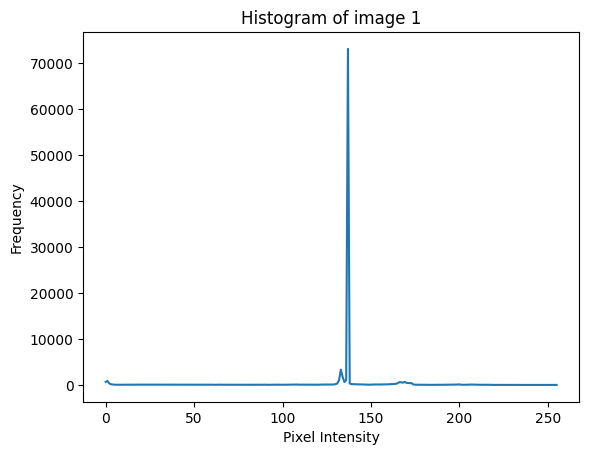

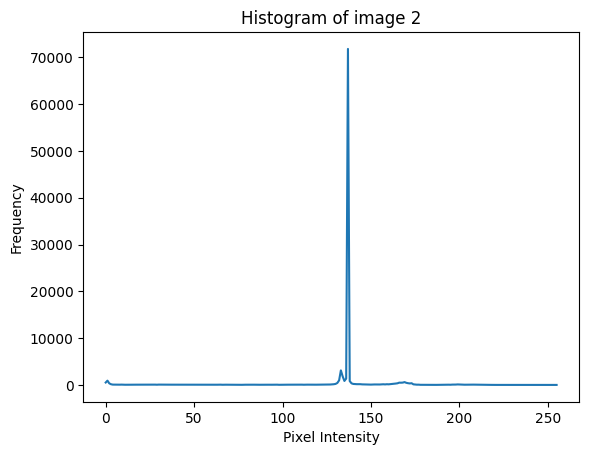

In [3]:
# convert from BGR (OpenCV default) to grayscale
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# calculate histogram array values
hist1 = cv2.calcHist([img1_gray], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([img2_gray], [0], None, [256], [0, 256])

# plot histograms for each image
for i, hist in enumerate([hist1, hist2]):
    plt.plot(hist)
    plt.title(f"Histogram of image {i+1}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

> 3) Compare the distributions between both images with Kolmogorov-Smirnov, Cross-Entropy, KL-Divergence, and JS-Divergence.

In [4]:
# Kolmogorov-Smirnov
kstest(hist1, hist2)

KstestResult(statistic=array([0.04296875]), pvalue=array([0.97260601]), statistic_location=array([62.]), statistic_sign=array([1.]))

In [5]:
# Cross-Entropy

# calculate probabilities for each frequency
prob1 = hist1 / sum(hist1)
prob2 = hist2 / sum(hist2)

# calculate entropies per image
print('Entropy of image 1:', entropy(prob1))
print('Entropy of image 2:', entropy(prob2))

Entropy of image 1: [1.7751656]
Entropy of image 2: [1.847654]


In [6]:
# KL-Divergence is infinite
print('KL(P||Q):', entropy(prob1, prob2))

# so add tiny epsilon as smoothing
eps=1e-12
print('KL(P||Q) with tiny epsilon smoothing:', entropy(prob1, prob2 + eps))

KL(P||Q): [inf]
KL(P||Q) with tiny epsilon smoothing: [0.00681197]


In [7]:
# JS-Divergence
m = (prob1 + prob2) / 2  # mean
js = (entropy(prob1, m) + entropy(prob2, m)) / 2
print('JS(P, Q):', js)

JS(P, Q): [0.00177137]


> Interpretation
>> 1. Kolmogorov-Smirnov: the value (0.04296875) is low, close to 0, so the distributions are similar
>> 2. Cross-Entropy: the values (1.7751656 and 1.847654) are fairly close, so the distributions are similar
>> 3. KL-Divergence: the value is infinite, so some smoothing is added, and the result (0.0068119676) is low, close to 0, so the distributions are similar
>> 4. JS-Divergence: the value (0.0017713667) is low, close to 0, so the distributions are similar

> These results are expected since image 2 differs from image 1 by just a drawn squiggly line, so the overall distributions are still similar

# Task 2

> 1. Create a random dataset in 3D space that has three clusters.
> 2. By using Expectation Maximization algorithms, try to implement Gaussian Mixture Modeling (GMM) clustering algorithm and cluster these data correctly.
> 3. Visualize at least two E and M steps in between.

Generating sample data using make_blobs...


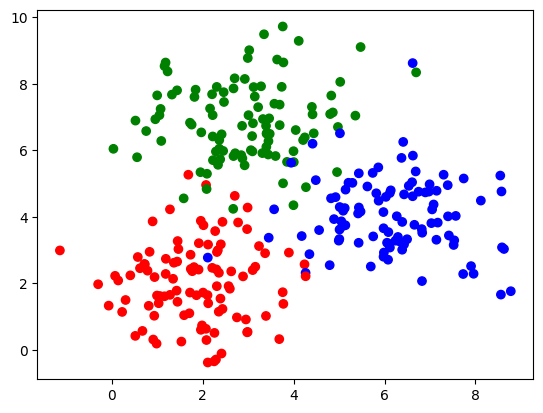

Generated 300 data points with 3 clusters
Data shape: (300, 2)
Cluster distribution: [100 100 100]

Fitting Gaussian Mixture Model...
Converged after 48 iterations

Number of steps 97

Visualizing EM algorithm steps...


/var/folders/6d/6xfccl7j6mbd39g5zmc885nc0000gp/T/ipykernel_89127/2279488365.py:192: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


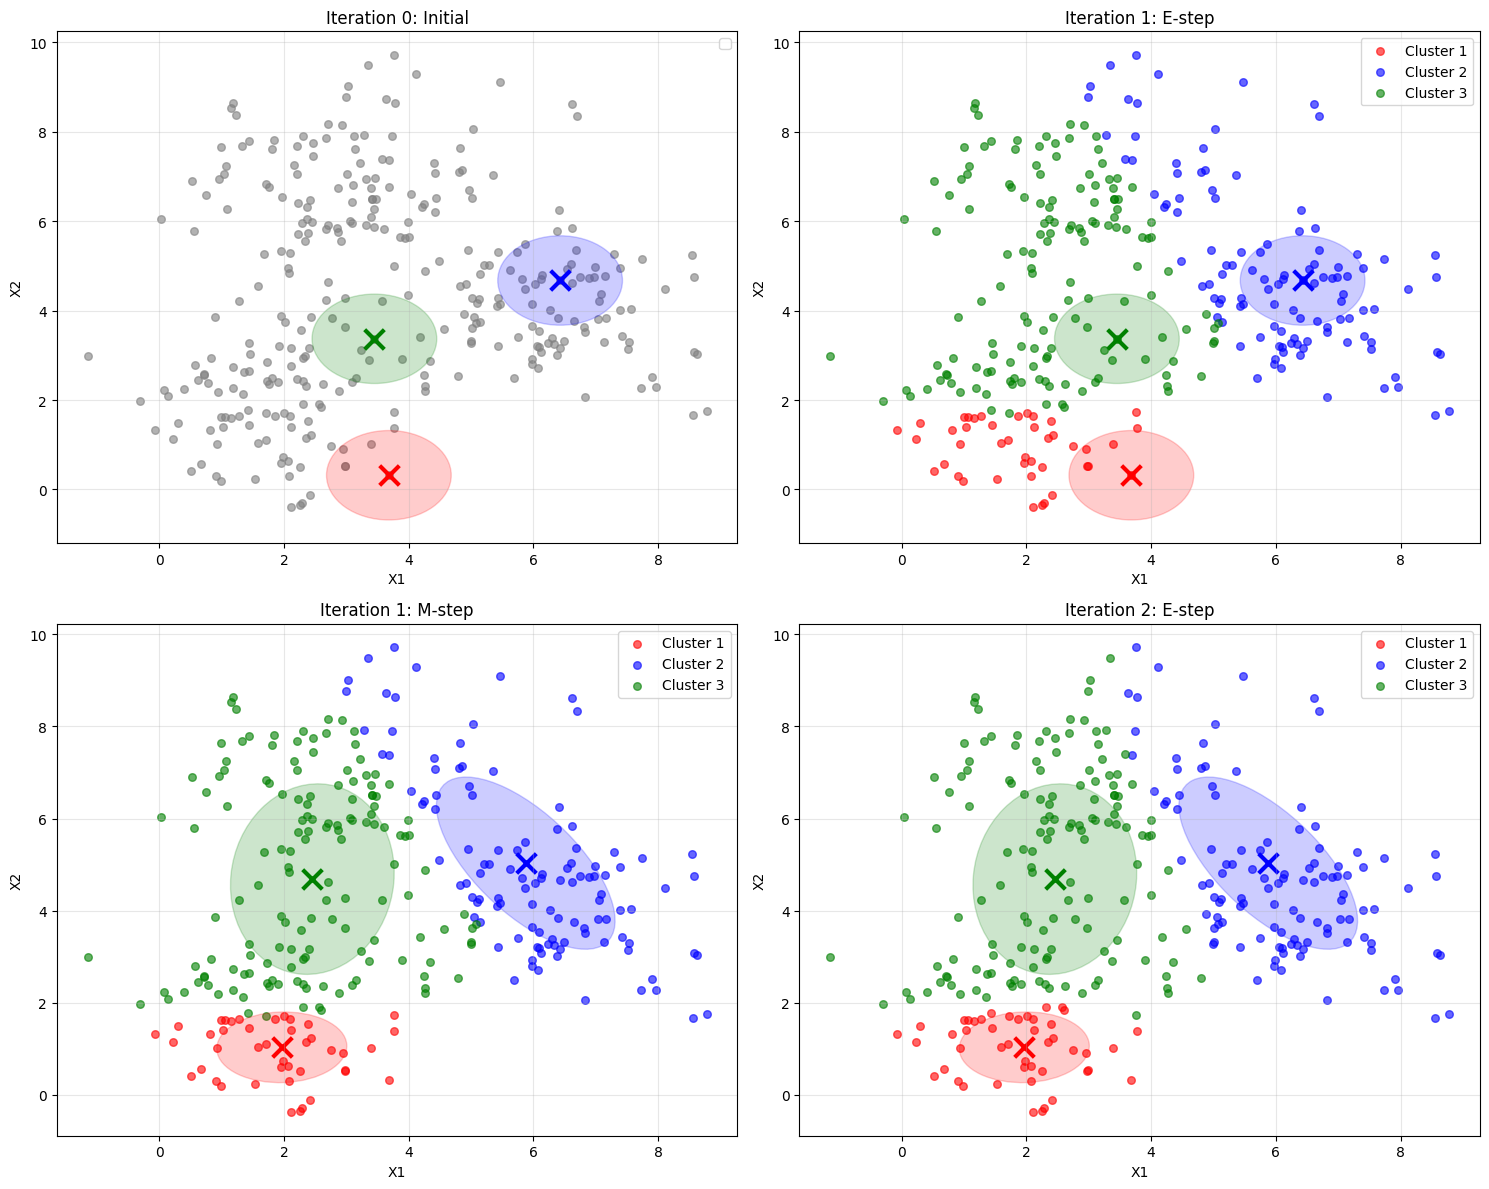


Final clustering completed
Final log-likelihood: -1226.75


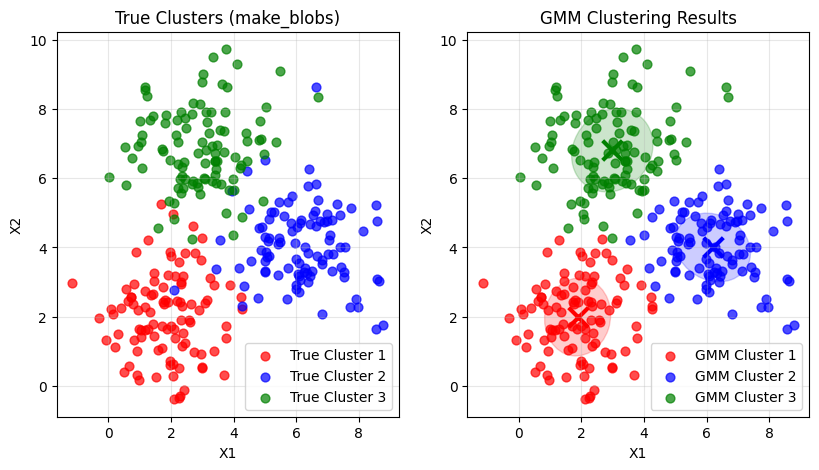

In [ ]:
class GaussianMixtureModel:
    def __init__(self, n_components=3, max_iter=100, tol=1e-6, random_state=42):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        
    def initialize_parameters(self, X):
        """ Initialize GMM parameters """
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        
        # initialize weights uniformly
        self.weights = np.ones(self.n_components) / self.n_components
        
        # initialize means randomly
        self.means = X[np.random.choice(n_samples, self.n_components, replace=False)]
        
        # initialize covariances as identity matrices
        self.covariances = np.array([np.eye(n_features) for _ in range(self.n_components)])
        
        # store history for visualization
        self.history = []
        self._save_state(0, "Initial")
        
    def _save_state(self, iteration, step_type, responsibilities=None):
        """Save current state for visualization"""
        state = {
            'iteration': iteration,
            'step_type': step_type,
            'weights': self.weights.copy(),
            'means': self.means.copy(),
            'covariances': self.covariances.copy(),
            'responsibilities': responsibilities.copy() if responsibilities is not None else None
        }
        self.history.append(state)
    
    def e_step(self, X):
        """Expectation step: compute responsibilities (probabilities)"""
        n_samples = X.shape[0]
        responsibilities = np.zeros((n_samples, self.n_components))
        
        # Calculate likelihood for each component
        for k in range(self.n_components):
            responsibilities[:, k] = self.weights[k] * multivariate_normal.pdf(
                X, self.means[k], self.covariances[k])
        
        # Normalize responsibilities
        total_responsibility = responsibilities.sum(axis=1, keepdims=True)
        # total_responsibility[total_responsibility == 0] = 1e-10  # Avoid division by zero
        responsibilities /= total_responsibility
        
        return responsibilities
    
    def m_step(self, X, responsibilities):
        """Maximization step: update parameters"""
        n_samples, n_features = X.shape
        
        # Update weights
        Nk = responsibilities.sum(axis=0)
        self.weights = Nk / n_samples
        
        # Update means
        for k in range(self.n_components):
            if Nk[k] > 0:
                self.means[k] = (responsibilities[:, k].reshape(-1, 1) * X).sum(axis=0) / Nk[k]
        
        # Update covariances
        for k in range(self.n_components):
            if Nk[k] > 0:
                diff = X - self.means[k]
                weighted_diff = responsibilities[:, k].reshape(-1, 1) * diff
                self.covariances[k] = (weighted_diff.T @ diff) / Nk[k]

    def log_likelihood(self, X):
        """Calculate log-likelihood of data"""
        ll = 0
        for i in range(X.shape[0]):
            sample_ll = 0
            for k in range(self.n_components):
                sample_ll += self.weights[k] * multivariate_normal.pdf(
                    X[i], self.means[k], self.covariances[k])
            ll += np.log(sample_ll + 1e-10)
        return ll
    
    def fit(self, X):
        """Fit GMM using EM algorithm"""
        self.initialize_parameters(X)
        
        prev_ll = -np.inf
        
        for iteration in range(1, self.max_iter + 1):
            # E-step
            responsibilities = self.e_step(X)
            self._save_state(iteration, f"E-step", responsibilities)
            
            # M-step
            self.m_step(X, responsibilities)
            self._save_state(iteration, f"M-step", responsibilities)
            
            # Check convergence
            current_ll = self.log_likelihood(X)
            if abs(current_ll - prev_ll) < self.tol:
                print(f"Converged after {iteration} iterations")
                break
            prev_ll = current_ll
            
        return self
    
    def predict(self, X):
        """Predict cluster assignments"""
        responsibilities = self.e_step(X)
        return np.argmax(responsibilities, axis=1)
    
    def predict_proba(self, X):
        """Predict cluster probabilities"""
        return self.e_step(X)

def generate_sample_data(n_samples=300, n_centers=3, random_state=42, cluster_std=1.5):
    """Generate sample data using make_blobs"""
    # Define cluster centers
    centers = [[2, 2], [6, 4], [3, 7]]
    
    X, true_labels = make_blobs(
        n_samples=n_samples,
        centers=centers[:n_centers],
        n_features=2,
        cluster_std=cluster_std,
        center_box=(0.0, 10.0),
        random_state=random_state
    )

    # visualize
    df = pd.DataFrame(X, columns=['x','y'])
    df['label'] = true_labels
    # Define fixed colors for each category
    color_map = {0: "red", 1: "blue", 2: "green"}
    # Map categories to colors
    colors = [color_map[val] for val in true_labels]
    plt.scatter(df['x'], df['y'], c=colors)
    plt.show()
    
    return X, true_labels

def plot_ellipse(mean, cov, ax, color, alpha=0.3):
    """Plot confidence ellipse for a 2D Gaussian"""
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    width, height = 2 * np.sqrt(eigenvals)
    
    ellipse = Ellipse(mean, width, height, angle=angle, 
                     facecolor=color, alpha=alpha, edgecolor=color)
    ax.add_patch(ellipse)

def visualize_em_steps(gmm, X, step_indices):
    """Visualize specific E and M steps"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    for i, step_idx in enumerate(step_indices):
        if step_idx >= len(gmm.history):
            continue
        ax = axes[i]
        state = gmm.history[step_idx]
        
        # Plot data points
        if state['responsibilities'] is not None:
            # Color by most likely cluster
            cluster_assignments = np.argmax(state['responsibilities'], axis=1)
            for k in range(gmm.n_components):
                mask = cluster_assignments == k
                ax.scatter(X[mask, 0], X[mask, 1], c=colors[k], 
                          alpha=0.6, s=30, label=f'Cluster {k+1}')
        else:
            ax.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.6, s=30)
        
        # Plot cluster centers and ellipses
        for k in range(gmm.n_components):
            # Plot mean
            ax.scatter(state['means'][k, 0], state['means'][k, 1], 
                      c=colors[k], s=200, marker='x', linewidths=3)
            
            # Plot confidence ellipse
            plot_ellipse(state['means'][k], state['covariances'][k], 
                        ax, colors[k], alpha=0.2)
        
        ax.set_title(f"Iteration {state['iteration']}: {state['step_type']}")
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

# Main execution
# Generate sample data using make_blobs
print("Generating sample data using make_blobs...")
X, true_labels = generate_sample_data(n_samples=300, n_centers=3, 
                                    random_state=42, cluster_std=1.2)

print(f"Generated {X.shape[0]} data points with {len(np.unique(true_labels))} clusters")
print(f"Data shape: {X.shape}")
print(f"Cluster distribution: {np.bincount(true_labels)}")

# Initialize and fit GMM
print("\nFitting Gaussian Mixture Model...")
gmm = GaussianMixtureModel(n_components=3, random_state=42)
gmm.fit(X)

# Visualize E and M steps
print("\nVisualizing EM algorithm steps...")
visualize_em_steps(gmm, X, step_indices=[0, 1, 2, 3])  # Initial, E1, M1, E2, M2

# Final clustering results
final_predictions = gmm.predict(X)
final_probabilities = gmm.predict_proba(X)

print(f"\nFinal clustering completed")
print(f"Final log-likelihood: {gmm.log_likelihood(X):.2f}")

# Plot final results
plt.figure(figsize=(15, 5))

# Original make_blobs data
plt.subplot(1, 3, 1)
colors = ['red', 'blue', 'green']
for k in range(len(np.unique(true_labels))):
    mask = true_labels == k
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[k], 
                alpha=0.7, s=40, label=f'True Cluster {k+1}')
plt.title('True Clusters (make_blobs)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True, alpha=0.3)

# GMM results
plt.subplot(1, 3, 2)
for k in range(gmm.n_components):
    mask = final_predictions == k
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[k], 
                alpha=0.7, s=40, label=f'GMM Cluster {k+1}')
    # Plot final means and ellipses
    plt.scatter(gmm.means[k, 0], gmm.means[k, 1], 
                c=colors[k], s=200, marker='x', linewidths=3)
    plot_ellipse(gmm.means[k], gmm.covariances[k], plt.gca(), colors[k], alpha=0.2)

plt.title('GMM Clustering Results')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True, alpha=0.3)